In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Importing dataset

df = pd.read_csv('toyota.csv')

# Display the first few rows of the the data set
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [3]:
# Looking for specific datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


In [4]:
# What are the top 3 indicators that influence price?

corr = df[['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']].corr()

corr

,price,year,mileage,tax,mpg,engineSize
price,1.000000,0.420959,-0.297936,0.214498,-0.039910,0.727592
year,0.420959,1.000000,-0.727749,0.283455,-0.020607,-0.045567
mileage,-0.297936,-0.727749,1.000000,-0.205285,0.044889,0.182615
tax,0.214498,0.283455,-0.205285,1.000000,-0.430292,0.155727
mpg,-0.039910,-0.020607,0.044889,-0.430292,1.000000,-0.106868
engineSize,0.727592,-0.045567,0.182615,0.155727,-0.106868,1.000000


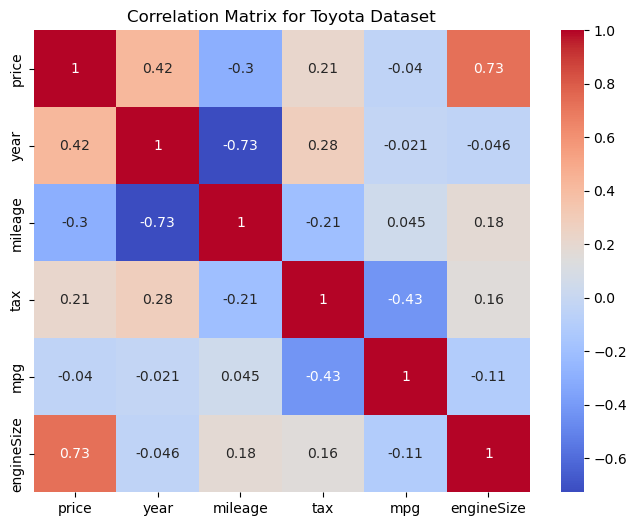

In [5]:
# Visualizing the Correlation

plt.figure(figsize = (8, 6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix for Toyota Dataset")
plt.show()

In [6]:
y = df['price']
X = df[['year', 'mileage', 'engineSize']]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



print("Model Evaluation Results:")
print("--------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation Results:
--------------------------
Mean Absolute Error (MAE): 2289.06
Mean Squared Error (MSE): 9980266.32
Root Mean Squared Error (RMSE): 3159.16
R² Score: 0.7655


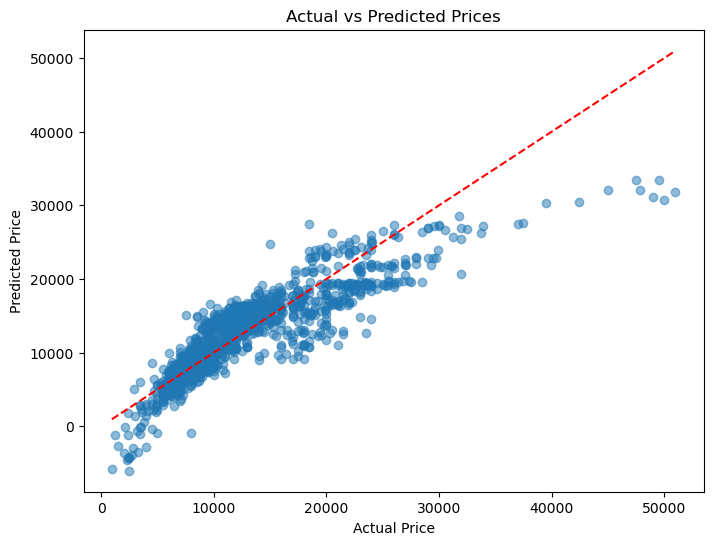

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

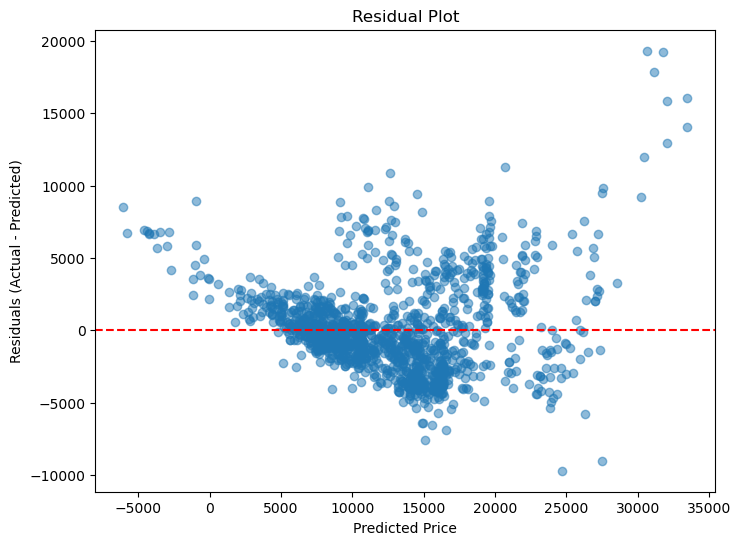

In [10]:
# Calculating for residual plot
residuals = y_test - y_pred

# Visualizing 
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [17]:
# ---- Expanding Linear Regression by adding tax and mpg ------

y = df['price']
X = df[['year', 'mileage', 'engineSize', 'tax', 'mpg']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



print("Model Evaluation Results:")
print("--------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation Results:
--------------------------
Mean Absolute Error (MAE): 2254.41
Mean Squared Error (MSE): 9962697.15
Root Mean Squared Error (RMSE): 3156.37
R² Score: 0.7659


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

In [21]:
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_y_pred)

print("Random Forest Model Evaluation Results:")
print("--------------------------------------")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")


Random Forest Model Evaluation Results:
--------------------------------------
Mean Absolute Error (MAE): 885.42
Mean Squared Error (MSE): 1884881.31
Root Mean Squared Error (RMSE): 1372.91
R² Score: 0.9557


In [22]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(rf_model, "models/random_forest_price_model.joblib")

['models/random_forest_price_model.joblib']